In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots 
import numpy as np

plt.style.use(["science","notebook", "grid"])

from funciones import joint_simulation

from ase.visualize import view
from ase.io import read, write

# Completed simulation

Untill today

In [4]:
md = joint_simulation(folders=["./outputs_1","./outputs_2"])


Processing folder: ./outputs_1
Processing file: pw.out.27896 ---- 217 frames
Processing file: pw.out.27972 ---- 177 frames
Processing file: pw.out.28006 ---- 228 frames
Processing file: pw.out.28046 ---- 201 frames
Processing file: pw.out.28099 ---- 169 frames
Total frames on ./outputs_1 folder: 992

Processing folder: ./outputs_2
Processing file: pw.out.28895 ---- 182 frames
Processing file: pw.out.28984 ---- 183 frames
Processing file: pw.out.29046 ---- 169 frames
Processing file: pw.out.29139 ---- 178 frames
Processing file: pw.out.29374 ---- 186 frames
Processing file: pw.out.29624 ---- 185 frames
Processing file: pw.out.29799 ---- 195 frames
Processing file: pw.out.29937 ---- 196 frames
Processing file: pw.out.30033 ---- 200 frames
Processing file: pw.out.30117 ---- 209 frames
Total frames on ./outputs_2 folder: 2875

Total frames in joint simulation: 2875


In [5]:
energies = np.zeros(len(md))
temperatures = np.zeros(len(md))
for i in range(len(md)):
	energies[i] = md[i].get_potential_energy()
	temperatures[i] = md[i].info['temperature']

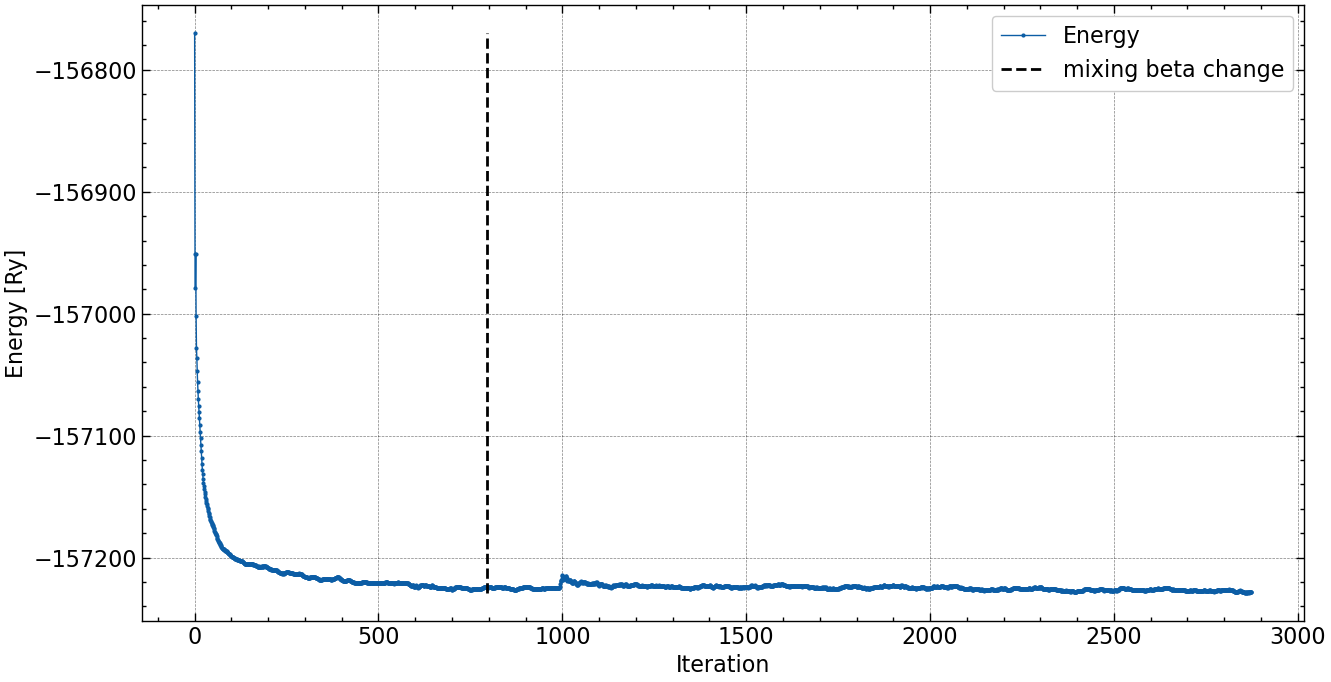

In [6]:
fig, ax = plt.subplots(1,1, figsize=(15,8))
ax.plot(energies, 'o-', ms = 2, linewidth = 1, label = 'Energy')
ax.vlines(x=794, ymax=np.max(energies), ymin=np.min(energies), label ="mixing beta change", color = 'black', linestyles='--')
ax.set_ylabel("Energy [Ry]")
ax.set_xlabel("Iteration")
ax.legend()
fig.savefig("energia.png")

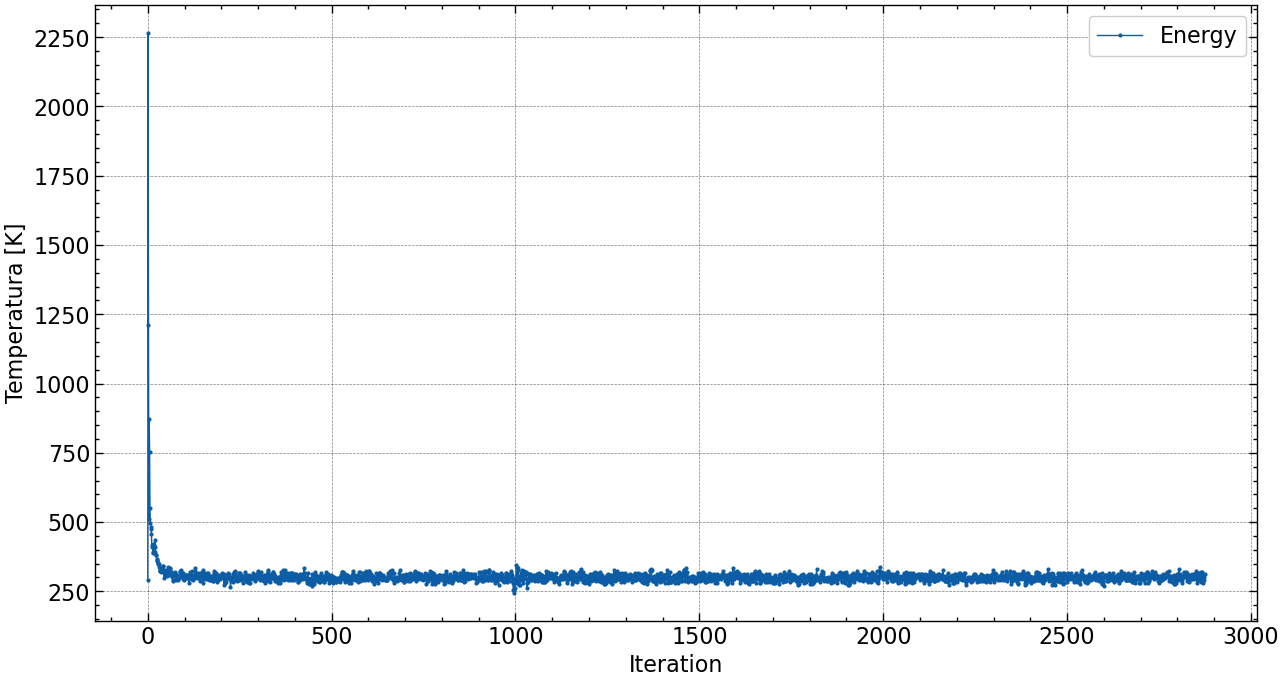

In [7]:
fig, ax = plt.subplots(1,1, figsize=(15,8))
ax.plot(temperatures, 'o-', ms = 2, linewidth = 1, label = 'Energy')
#ax.vlines(x=794, ymax=np.max(energies), ymin=np.min(energies), label ="mixing beta change", color = 'black', linestyles='--')
ax.set_ylabel("Temperatura [K]")
ax.set_xlabel("Iteration")
ax.legend()
fig.savefig("temperatura.png")

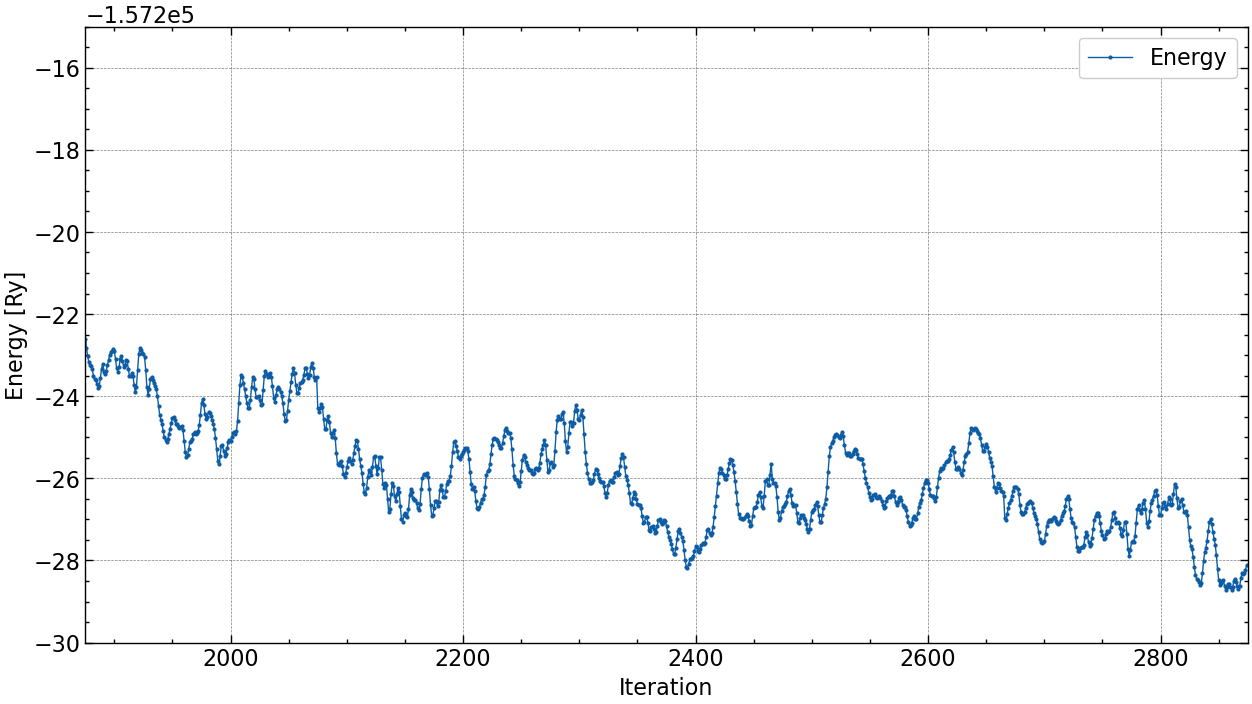

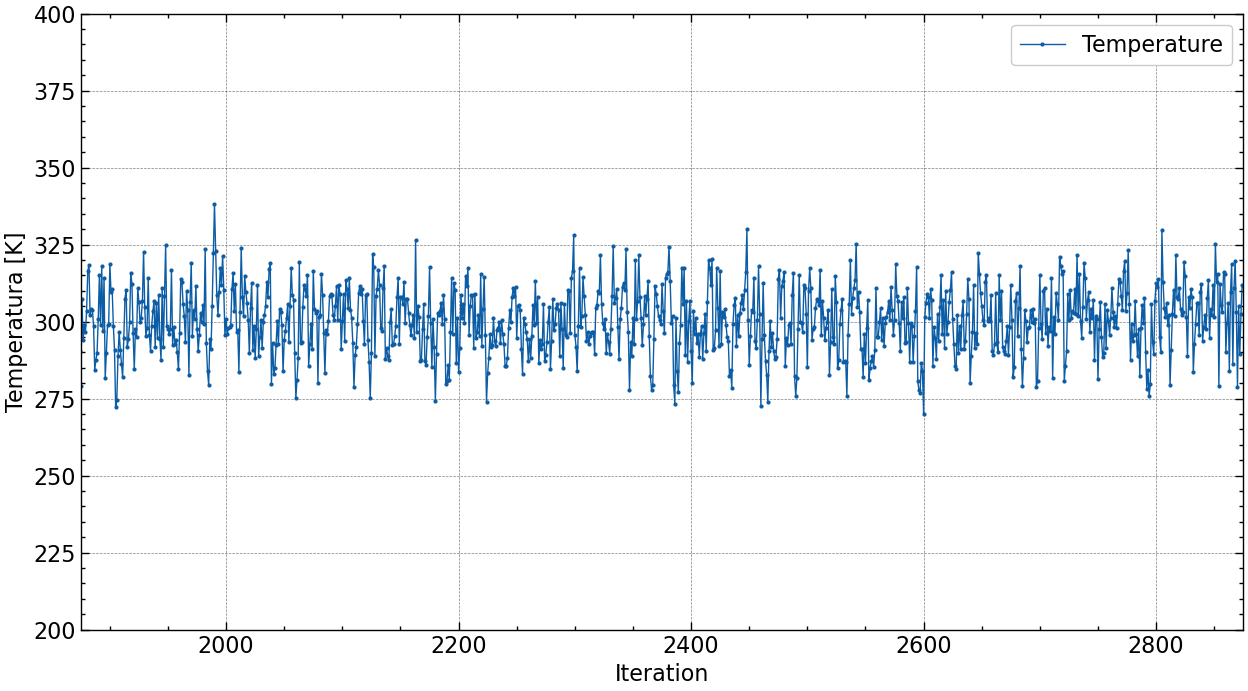

In [8]:
# === PRIMERA GRAFICA: Energía ===

fig, ax = plt.subplots(1,1, figsize=(15,8))
ax.plot(energies, 'o-', ms=2, linewidth=1, label='Energy')
#ax.vlines(x=794, ymax=np.max(energies), ymin=np.min(energies),label="mixing beta change", color='black', linestyles='--')

# ZOOM en las ultimas 1000 iteraciones
N = len(energies)
ax.set_xlim(max(0, N-1000), N)
ax.set_ylim(ymax=-157215, ymin= -157230)

ax.set_ylabel("Energy [Ry]")
ax.set_xlabel("Iteration")
ax.legend()
fig.savefig("energia_zoom.png")


# === SEGUNDA GRAFICA: Temperatura ===

fig, ax = plt.subplots(1,1, figsize=(15,8))
ax.plot(temperatures, 'o-', ms=2, linewidth=1, label='Temperature')

# ZOOM en las ultimas 1000 iteraciones
N2 = len(temperatures)
ax.set_xlim(max(0, N2-1000), N2)
ax.set_ylim(200,400)

ax.set_ylabel("Temperatura [K]")
ax.set_xlabel("Iteration")
ax.legend()
fig.savefig("temperatura_zoom.png")


In [9]:
from ase.geometry.analysis import get_rdf

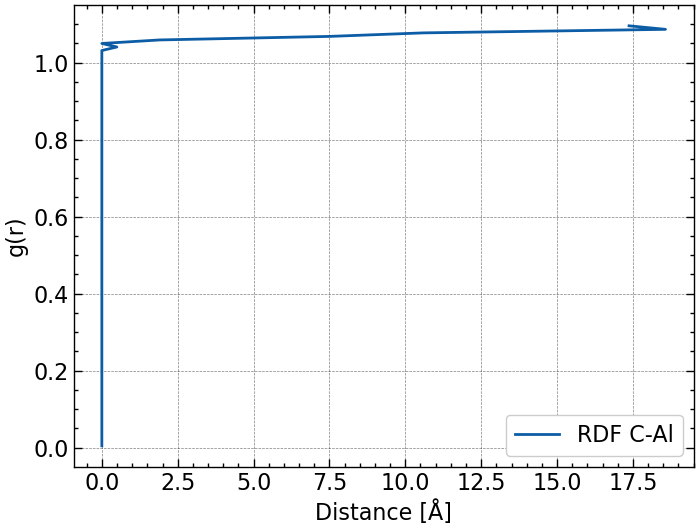

In [15]:
fig, ax = plt.subplots(1,1, figsize=(8,6))
r, rdf = get_rdf(md[-1],1.1,120)
ax.plot(r, rdf, label='RDF C-Al')
ax.set_xlabel("Distance [Å]")
ax.set_ylabel("g(r)")
ax.legend()
